In [2]:
# Bibliotecas necessárias — todas já vêm no Colab, sem instalar nada
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Criando a conexão com o banco de dados 
conn = sqlite3.connect('student_performance.db')

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

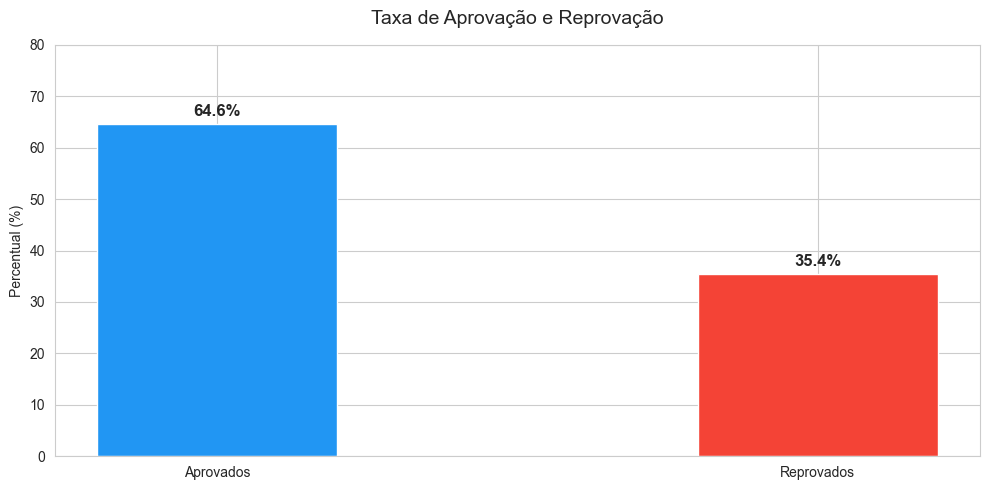

resultado  total_alunos  percentual
      Yes           323        64.6
       No           177        35.4


In [10]:
# Query 1 — Taxa geral de aprovação

query = """
    SELECT
        passed AS resultado,
        COUNT(*) AS total_alunos,
        ROUND(COUNT(*) * 100.0 / 500, 1) AS percentual
    FROM student_performance
    GROUP BY passed
    ORDER BY passed DESC
"""

df_aprovacao = pd.read_sql_query(query, conn)

# Gráfico de barras
fig, ax = plt.subplots()

cores = ['#2196F3', '#F44336']  # azul para aprovado, vermelho para reprovado
barras = ax.bar(df_aprovacao['resultado'], df_aprovacao['percentual'], color=cores, width=0.4)

# Rótulos em cima de cada barra
for barra, valor in zip(barras, df_aprovacao['percentual']):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 1,
            f'{valor}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Taxa de Aprovação e Reprovação', fontsize=14, pad=15)
ax.set_ylabel('Percentual (%)')
ax.set_ylim(0, 80)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Aprovados', 'Reprovados'])

plt.tight_layout()
plt.savefig('graficos/grafico1_aprovacao_geral.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_aprovacao.to_string(index=False))

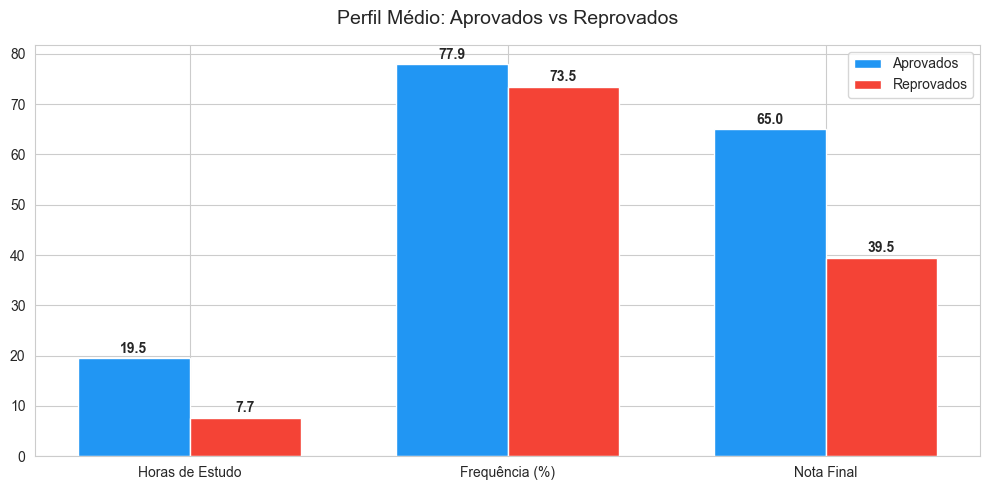

In [11]:
# Query 2 — Perfil médio dos grupos

query = """
    SELECT
        passed AS resultado,
        ROUND(AVG(study_hours_per_week), 1) AS media_horas_estudo,
        ROUND(AVG(attendance_rate), 1) AS media_frequencia,
        ROUND(AVG(final_score), 1) AS media_nota_final
    FROM student_performance
    GROUP BY passed
    ORDER BY passed DESC
"""

df_perfil = pd.read_sql_query(query, conn)

# Gráfico de barras agrupadas
metricas = ['media_horas_estudo', 'media_frequencia', 'media_nota_final']
labels = ['Horas de Estudo', 'Frequência (%)', 'Nota Final']

x = range(len(metricas))
largura = 0.35

fig, ax = plt.subplots()

barras_sim = ax.bar([i - largura/2 for i in x],
                    df_perfil[df_perfil['resultado']=='Yes'][metricas].values[0],
                    largura, label='Aprovados', color='#2196F3')

barras_nao = ax.bar([i + largura/2 for i in x],
                    df_perfil[df_perfil['resultado']=='No'][metricas].values[0],
                    largura, label='Reprovados', color='#F44336')

# Rótulos
for barra in barras_sim:
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 0.5,
            str(round(barra.get_height(), 1)),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

for barra in barras_nao:
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 0.5,
            str(round(barra.get_height(), 1)),
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Perfil Médio: Aprovados vs Reprovados', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.savefig('graficos/grafico2_perfil_medio.png', dpi=150, bbox_inches='tight')
plt.show()

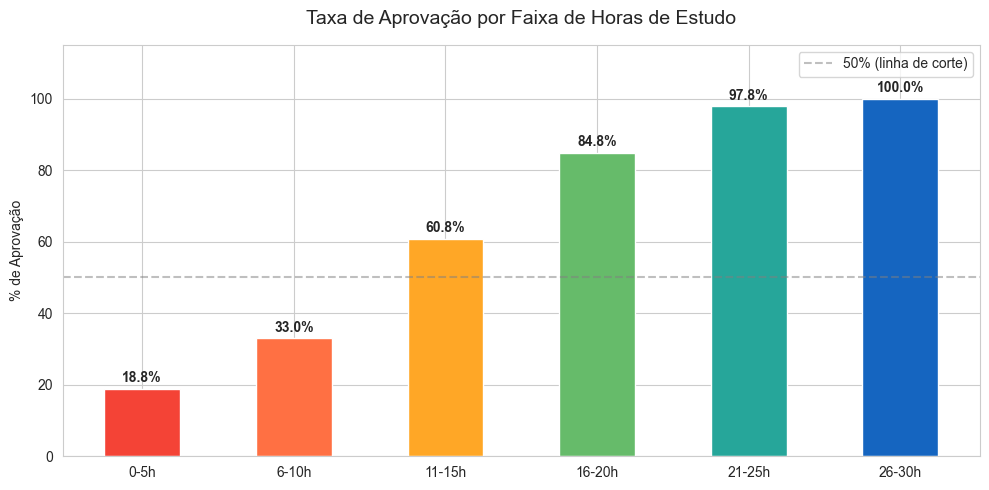

In [12]:
# Query 3 — Aprovação por faixa de horas de estudo

query = """
    SELECT
        CASE
            WHEN study_hours_per_week BETWEEN 0  AND 5  THEN '01_0-5h'
            WHEN study_hours_per_week BETWEEN 6  AND 10 THEN '02_6-10h'
            WHEN study_hours_per_week BETWEEN 11 AND 15 THEN '03_11-15h'
            WHEN study_hours_per_week BETWEEN 16 AND 20 THEN '04_16-20h'
            WHEN study_hours_per_week BETWEEN 21 AND 25 THEN '05_21-25h'
            WHEN study_hours_per_week BETWEEN 26 AND 30 THEN '06_26-30h'
        END AS faixa_horas,
        ROUND(
            SUM(CASE WHEN passed = 'Yes' THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*), 1
        ) AS pct_aprovacao
    FROM student_performance
    GROUP BY faixa_horas
    ORDER BY faixa_horas
"""

df_faixas = pd.read_sql_query(query, conn)

# Remove o prefixo numérico só para exibição no gráfico
df_faixas['faixa_label'] = df_faixas['faixa_horas'].str.replace(r'^\d+_', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 5))

cores_faixas = ['#F44336','#FF7043','#FFA726','#66BB6A','#26A69A','#1565C0']
barras = ax.bar(df_faixas['faixa_label'], df_faixas['pct_aprovacao'],
                color=cores_faixas, width=0.5)

for barra, valor in zip(barras, df_faixas['pct_aprovacao']):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 1,
            f'{valor}%', ha='center', va='bottom', fontweight='bold')

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% (linha de corte)')
ax.set_title('Taxa de Aprovação por Faixa de Horas de Estudo', fontsize=14, pad=15)
ax.set_ylabel('% de Aprovação')
ax.set_ylim(0, 115)
ax.legend()

plt.tight_layout()
plt.savefig('graficos/grafico3_aprovacao_por_horas.png', dpi=150, bbox_inches='tight')
plt.show()

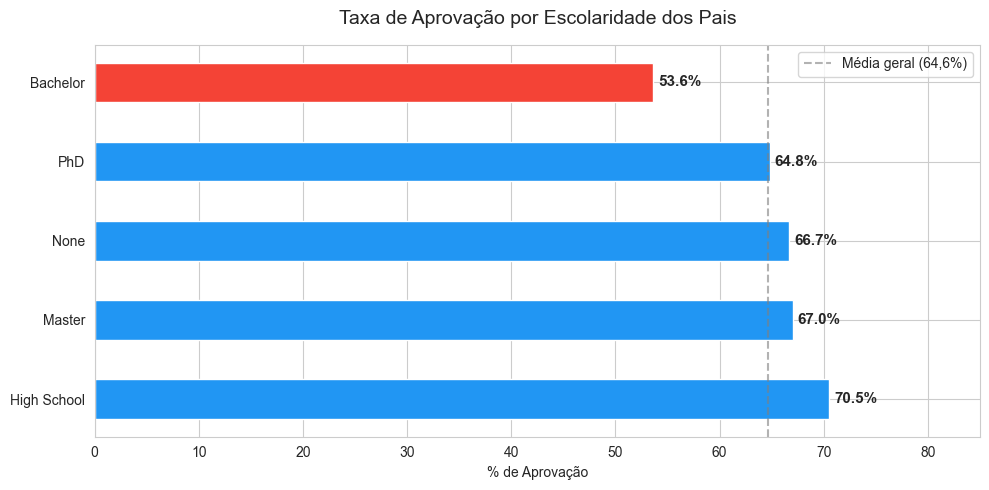

In [13]:
# Query 5 — Aprovação por escolaridade dos pais

query = """
    SELECT
        parent_education AS escolaridade_pais,
        COUNT(*) AS total_alunos,
        ROUND(
            SUM(CASE WHEN passed = 'Yes' THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*), 1
        ) AS pct_aprovacao
    FROM student_performance
    GROUP BY parent_education
    ORDER BY pct_aprovacao DESC
"""

df_edu = pd.read_sql_query(query, conn)

df_edu['escolaridade_pais'] = df_edu['escolaridade_pais'].fillna('None')  # ← adicionar essa linha

fig, ax = plt.subplots(figsize=(10, 5))

# Cores destacando a anomalia: Bachelor (menor) em vermelho, demais em azul
cores = ['#2196F3' if edu != 'Bachelor' else '#F44336'
         for edu in df_edu['escolaridade_pais']]

barras = ax.barh(df_edu['escolaridade_pais'], df_edu['pct_aprovacao'],
                 color=cores, height=0.5)

# Rótulos ao lado de cada barra
for barra, valor in zip(barras, df_edu['pct_aprovacao']):
    ax.text(barra.get_width() + 0.5,
            barra.get_y() + barra.get_height()/2,
            f'{valor}%', va='center', fontweight='bold', fontsize=11)

ax.axvline(x=64.6, color='gray', linestyle='--', alpha=0.6,
           label='Média geral (64,6%)')
ax.set_title('Taxa de Aprovação por Escolaridade dos Pais', fontsize=14, pad=15)
ax.set_xlabel('% de Aprovação')
ax.set_xlim(0, 85)
ax.legend()

plt.tight_layout()
plt.savefig('graficos/grafico4_escolaridade_pais.png', dpi=150, bbox_inches='tight')
plt.show()

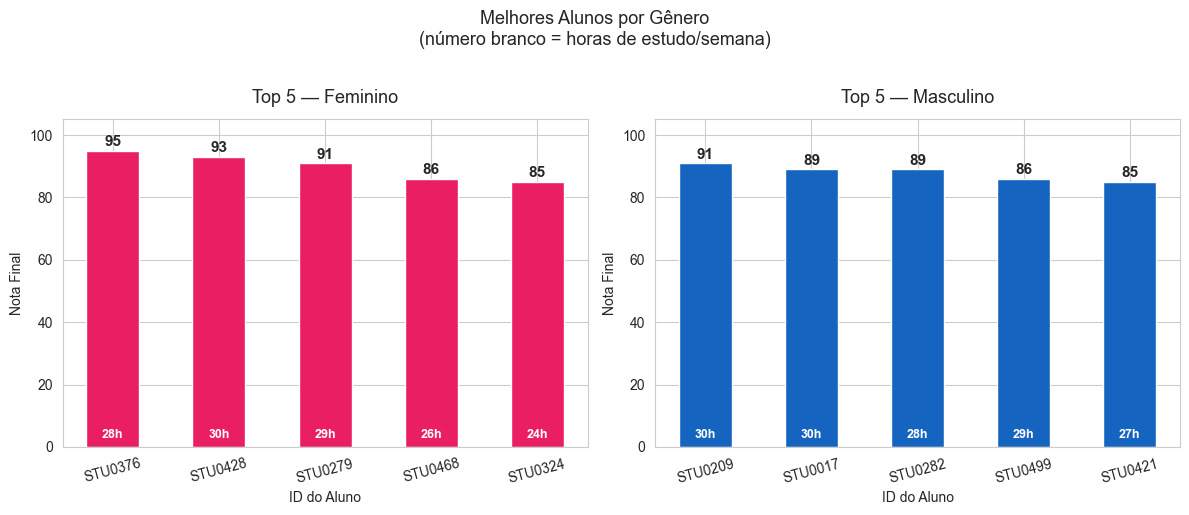

In [14]:
# Query 7 —  Ranking dos melhores alunos

query = """
    WITH ranking AS (
        SELECT
            student_id,
            gender,
            final_score,
            study_hours_per_week,
            attendance_rate,
            RANK() OVER (
                PARTITION BY gender
                ORDER BY final_score DESC
            ) AS posicao
        FROM student_performance
    )
    SELECT *
    FROM ranking
    WHERE posicao <= 5
    ORDER BY gender, posicao
"""

df_top = pd.read_sql_query(query, conn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, genero in enumerate(['Female', 'Male']):
    df_g = df_top[df_top['gender'] == genero].reset_index(drop=True)
    ax = axes[i]

    cores_barras = ['#E91E63' if genero == 'Female' else '#1565C0'] * 5

    barras = ax.bar(df_g['student_id'], df_g['final_score'],
                    color=cores_barras, width=0.5)

    # Rótulo com nota em cima e horas de estudo abaixo
    for barra, nota, horas in zip(barras, df_g['final_score'],
                                   df_g['study_hours_per_week']):
        ax.text(barra.get_x() + barra.get_width()/2,
                barra.get_height() + 0.5,
                str(int(nota)),
                ha='center', va='bottom', fontweight='bold', fontsize=11)
        ax.text(barra.get_x() + barra.get_width()/2,
                2,
                f'{int(horas)}h',
                ha='center', va='bottom', fontsize=9,
                color='white', fontweight='bold')

    titulo = 'Top 5 — Feminino' if genero == 'Female' else 'Top 5 — Masculino'
    ax.set_title(titulo, fontsize=13, pad=12)
    ax.set_ylabel('Nota Final')
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=15)
    ax.set_xlabel('ID do Aluno')

fig.suptitle('Melhores Alunos por Gênero\n(número branco = horas de estudo/semana)',
             fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('graficos/grafico5_top_alunos_genero.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
import os
print(os.getcwd())

C:\Users\nicol\Documents\projetos-dados\student-performance-analysis
